# Lecture 05

# MLE: Position of a Star

Dati generati: [1.0093243  0.96494174 1.17869189 1.06197189 1.09865121 0.73051964
 0.99160505 0.9625045  1.08991653 1.15311958]


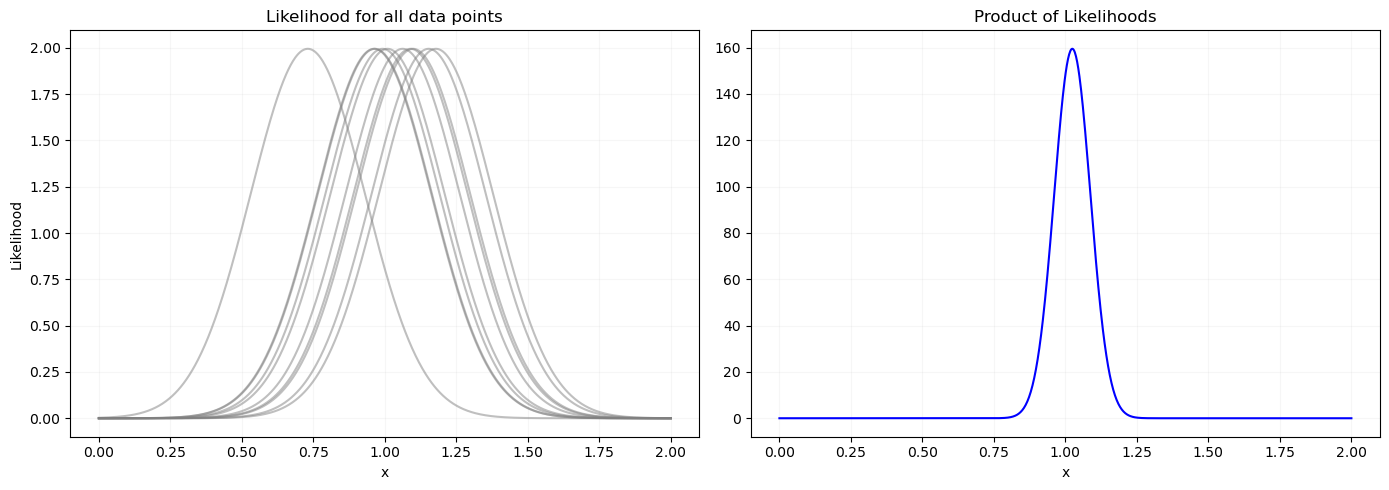

Stima MLE numerica (dal grafico): 1.0250
Stima MLE analitica (formula esatta): 1.0241


In [10]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm

mu = 1
sigma = 0.2
N = 10

# Generate fake measurements following a normal distribution
data = np.random.normal(mu, sigma, N)
print("Dati generati:", data)

# Create a grid of x values
x = np.linspace(0, 2, 1000)
likelihoods = []

fig, axs = plt.subplots(1, 2, figsize=(14, 5))

for d in data: 
    like = norm.pdf(x, loc=d, scale=sigma)  #sample each gaussian computing the pdf for each x
    likelihoods.append(like)
    axs[0].plot(x, like, alpha=0.5, color='gray') 

axs[0].set_title('Likelihood for all data points')
axs[0].set_xlabel('x')
axs[0].set_ylabel('Likelihood')
axs[0].grid(alpha=0.1)

total_likelihood = np.prod(likelihoods, axis=0)

axs[1].plot(x, total_likelihood, color='blue')
axs[1].set_title('Product of Likelihoods')
axs[1].set_xlabel('x')
axs[1].grid(alpha=0.1)

plt.tight_layout()
plt.show()

#compare MLE
mle_estimate = x[np.argmax(total_likelihood)]       # x per cui MLE è massimo
analytical_mle = np.mean(data)                      # lo stimatore MLE x gauss homosched è la mean

print(f"Stima MLE numerica (dal grafico): {mle_estimate:.4f}")
print(f"Stima MLE analitica (formula esatta): {analytical_mle:.4f}")


### Part 2

We want to verify how much precise is our estimate of the MLE computing the Fisher Information to compute the sigma relative to the MLE. \
We do it using the proper formula for the Fisher Information. Then we compare to the analitical error expected. 

Approccio Numerico: Informazione di Fisher (Osservata)

$$ \mathcal{I}(\hat{\mu}) = - \left. \frac{\partial^2 \ln \mathcal{L}(\mu)}{\partial \mu^2} \right|_{\mu = \hat{\mu}_{MLE}} $$

Da cui si ricava l'incertezza statistica a $1\sigma$:

$$ \sigma_{Fisher} = \frac{1}{\sqrt{\mathcal{I}(\hat{\mu})}} $$

Approccio Analitico (Sotto assunzione Gaussiana)

$$ \sigma_{analitico} = \frac{\sigma}{\sqrt{N}} $$

Errore stimato numericamente (Fisher): 0.06325
Errore analitico atteso: 0.06325


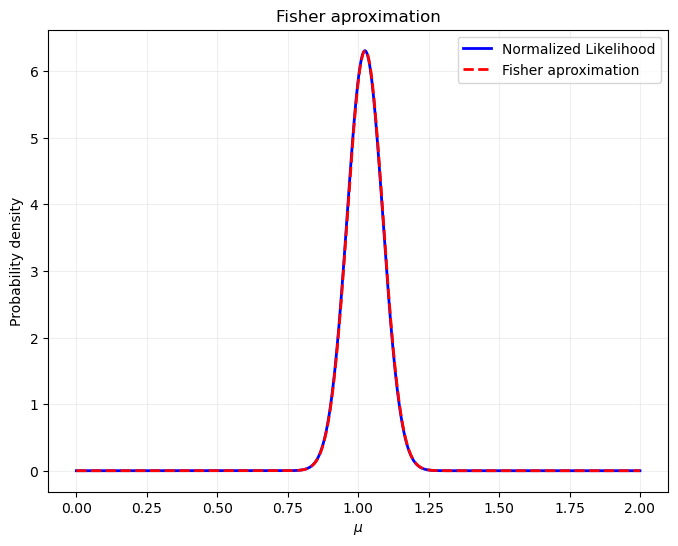

In [13]:
log_likelihoods = []
for d in data: 
    log_like = norm.logpdf(x, loc=d, scale=sigma)
    log_likelihoods.append(log_like)

total_log_likelihood = np.sum(log_likelihoods, axis=0)

dx = x[1] - x[0]
d2_log_like = np.diff(total_log_likelihood, n=2) / (dx**2)

#NB: due to FD derivatives at each order of derivatives we lose one element
#Solution: rescale x axis
x_diff = x[1:-1]

mle_idx = np.argmin(np.abs(x_diff - mle_estimate)) #find on x the position of mle
fisher_info = -d2_log_like[mle_idx]
fisher_error = np.sqrt(1 / fisher_info) # uncertanty on theta hat mle
analytical_error = sigma / np.sqrt(N)

print(f"Errore stimato numericamente (Fisher): {fisher_error:.5f}")
print(f"Errore analitico atteso: {analytical_error:.5f}")

#check accuracy of the method visually
#calcolo normalizzazione con metodo trapezi
plt.figure(figsize=(8, 6))
area_likelihood = np.trapezoid(total_likelihood, x)
plt.plot(x, total_likelihood / area_likelihood, 
         label='Normalized Likelihood', color='blue', lw=2)

fisher_gaussian = norm.pdf(x, loc=mle_estimate, scale=fisher_error)
plt.plot(x, fisher_gaussian, 
         label='Fisher aproximation', color='red', linestyle='--', lw=2)

plt.title('Fisher aproximation')
plt.xlabel(rf'$\mu$')
plt.ylabel('Probability density')
plt.legend()
plt.grid(alpha=0.2)
plt.show()

### Part 3

Let's make our model more realistic. Our  measurements were taken in different nights, where the sky behaved differently (i.e. errors are heteoscedastic). \
Let's assume that each measurment has a that is normally distributed with mean  and standard deviation.

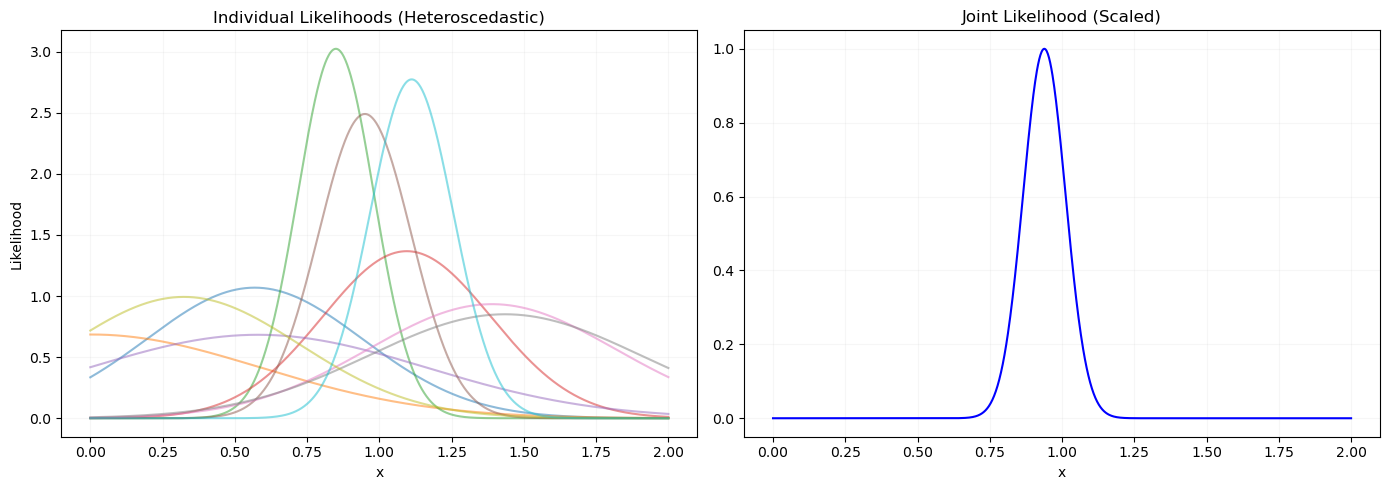

Stima MLE numerica: 0.9389
Stima MLE analitica (media pesata): 0.9386
Errore stimato numericamente (Fisher): 0.07337
Errore analitico atteso: 0.07337


In [12]:
from scipy.stats import alpha
np.random.seed(221)
N = 10
true_mu = 1.0

sigma_het = np.random.uniform(0.1, 0.6, N)
data_het = np.random.normal(loc=true_mu, scale=sigma_het)

x = np.linspace(0, 2, 1000)
dx = x[1] - x[0]

log_likelihoods_het = []

fig, axs = plt.subplots(1, 2, figsize=(14, 5))

for d, s in zip(data_het, sigma_het):
    # compute the pdf to draw different gaussians
    like = norm.pdf(x, loc=d, scale=s)
    axs[0].plot(x, like, alpha=0.5)
    # evaluate x for each gaussian
    log_like = norm.logpdf(x, loc=d, scale=s)
    log_likelihoods_het.append(log_like)

axs[0].set_title('Individual Likelihoods (Heteroscedastic)')
axs[0].set_xlabel('x')
axs[0].set_ylabel('Likelihood')
axs[0].grid(alpha=0.1)

#build the total log like
total_log_likelihood_het = np.sum(log_likelihoods_het, axis=0)

# to draw get back the total likelihood and not ist logarithm
total_likelihood_het = np.exp(total_log_likelihood_het - np.max(total_log_likelihood_het))
axs[1].plot(x, total_likelihood_het, color='blue')
axs[1].set_title('Joint Likelihood (Scaled)')
axs[1].set_xlabel('x')
axs[1].grid(alpha=0.1)

plt.tight_layout()
plt.show()

#mle estimates, analitically and numerically
mle_estimate_num = x[np.argmax(total_log_likelihood_het)]
weights = 1.0 / (sigma_het**2)
mle_estimate_ana = np.sum(data_het * weights) / np.sum(weights)

print(f"Stima MLE numerica: {mle_estimate_num:.4f}")
print(f"Stima MLE analitica (media pesata): {mle_estimate_ana:.4f}")

#mle uncertanty estimates, analitically and numerically
d2_log_like_het = np.diff(total_log_likelihood_het, n=2) / (dx**2)
x_diff = x[1:-1]

mle_idx = np.argmin(np.abs(x_diff - mle_estimate_num))
fisher_info_het = -d2_log_like_het[mle_idx]
fisher_error_num = np.sqrt(1 / fisher_info_het)

analytical_error_ana = np.sqrt(1 / np.sum(weights))

print(f"Errore stimato numericamente (Fisher): {fisher_error_num:.5f}")
print(f"Errore analitico atteso: {analytical_error_ana:.5f}")
